# AI-Assisted Linear Regression in R

This notebook uses R to examine the relationship between years of experience and salary. It loads the dataset, creates visualizations, fits a linear regression model, and evaluates the model.

In [4]:
data <- read.csv(
  "regression_data-1.csv",
  check.names = FALSE
)

head(data)

,YearsExperience,Salary
,<dbl>,<dbl>
1,1.1,39343
2,1.3,46205
3,1.5,37731
4,2.0,43525
5,2.2,39891
6,2.9,56642


In [5]:
str(data)
summary(data)

'data.frame':	10 obs. of  2 variables:
 $ YearsExperience: num  1.1 1.3 1.5 2 2.2 2.9 3 3.2 3.7 4
 $ Salary         : num  39343 46205 37731 43525 39891 ...


 YearsExperience     Salary     
 Min.   :1.100   Min.   :37731  
 1st Qu.:1.625   1st Qu.:40800  
 Median :2.550   Median :50325  
 Mean   :2.490   Mean   :49834  
 3rd Qu.:3.150   3rd Qu.:57052  
 Max.   :4.000   Max.   :63218  

In [7]:
required_columns <- c(
  "YearsExperience",
  "Salary"
)

missing_columns <- setdiff(
  required_columns,
  names(data)
)

if (length(missing_columns) > 0) {
  stop(
    paste(
      "Missing required column(s):",
      paste(missing_columns, collapse = ", ")
    )
  )
}

In [8]:
data$YearsExperience <- as.numeric(
  data$YearsExperience
)

data$Salary <- as.numeric(
  data$Salary
)

data <- data[
  complete.cases(
    data$YearsExperience,
    data$Salary
  ),
]

cat(
  "Number of usable observations:",
  nrow(data),
  "\n"
)

Number of usable observations: 10 


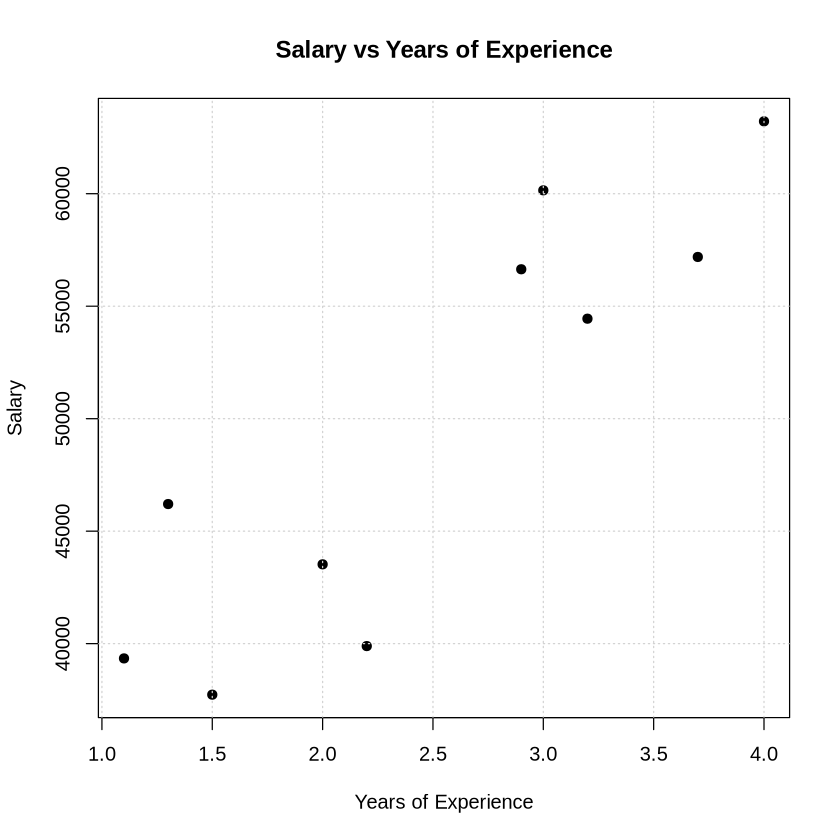

In [9]:
plot(
  data$YearsExperience,
  data$Salary,
  pch = 19,
  main = "Salary vs Years of Experience",
  xlab = "Years of Experience",
  ylab = "Salary"
)

grid()

In [10]:
model <- lm(
  Salary ~ YearsExperience,
  data = data
)

summary(model)


Call:
lm(formula = Salary ~ YearsExperience, data = data)

Residuals:
    Min      1Q  Median      3Q     Max 
-7540.2 -2564.9  -199.1  2814.8  6230.6 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)        29204       4092   7.136 9.84e-05 ***
YearsExperience     8285       1532   5.407 0.000641 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4680 on 8 degrees of freedom
Multiple R-squared:  0.7852,	Adjusted R-squared:  0.7583 
F-statistic: 29.24 on 1 and 8 DF,  p-value: 0.0006407


In [11]:
r_squared <- summary(model)$r.squared

rmse <- sqrt(
  mean(residuals(model)^2)
)

cat(
  "Intercept:",
  coef(model)[1],
  "\n"
)

cat(
  "Slope:",
  coef(model)[2],
  "\n"
)

cat(
  "R-squared:",
  r_squared,
  "\n"
)

cat(
  "RMSE:",
  rmse,
  "\n"
)

Intercept: 29203.52 
Slope: 8285.292 
R-squared: 0.7851516 
RMSE: 4186.149 


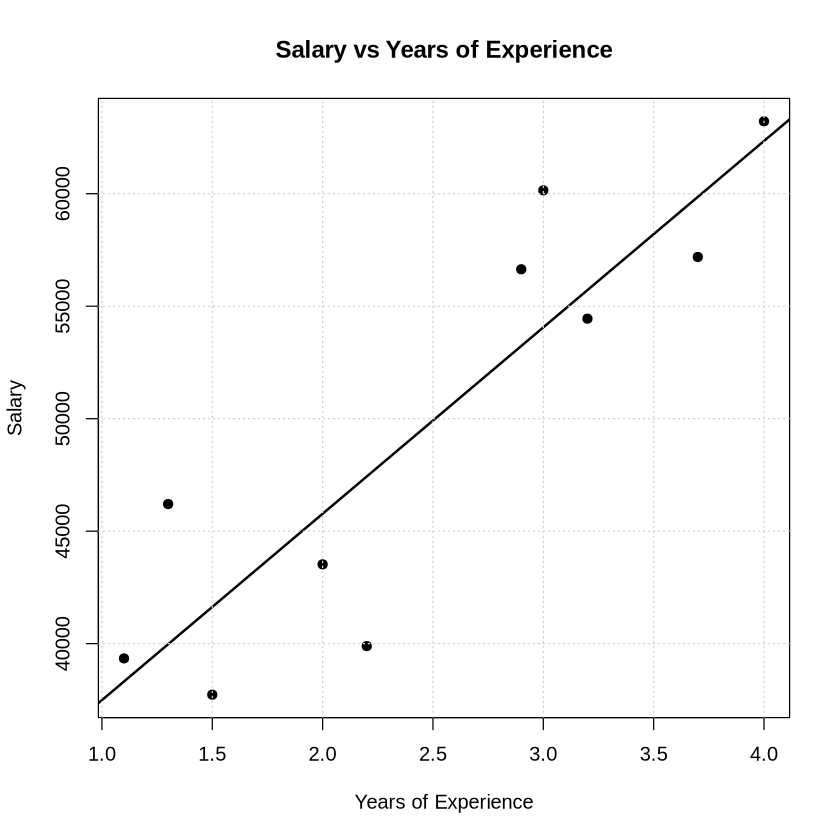

In [12]:
plot(
  data$YearsExperience,
  data$Salary,
  pch = 19,
  main = "Salary vs Years of Experience",
  xlab = "Years of Experience",
  ylab = "Salary"
)

abline(
  model,
  lwd = 2
)

grid()